# Libs

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
from pathlib import Path
import joblib
from sklearn.model_selection import ParameterGrid
from tqdm.auto import tqdm

import os
import logging
import sys
sys.path.append('../')
import src.forecasting.simulations      as sim
import src.fda.kde.estimators           as kde
import src.fda.transformations.lqdt     as lqdt

import src.fda.utils                    as fdaUtils
import src.forecasting.pipelines        as fp
import src.forecasting.accuracy         as acc
import src.forecasting.cross_validation as crossVal
import src.fda.dfpc as dfpc

In [22]:
EXECUTION_DATE : str = datetime.now().strftime('%Y%m%d')
# EXECUTION_DATE = '20260503'

LOG_PATH       : str = f'../logs/simulations/{EXECUTION_DATE}.log'
FILES_PATH     : str = f'../data/interim/simulation/{EXECUTION_DATE}/'
DATABASES_PATH : str = f'../data/interim/simulation/{EXECUTION_DATE}/databases/'
SIM_LQD_PATH       : str = f'../data/interim/simulation/{EXECUTION_DATE}/sim_lqds/'
KDE_LQD_PATH   : str = f'../data/interim/simulation/{EXECUTION_DATE}/kde_lqds/'
ALL_KDES_PATH  : str = f'../data/interim/simulation/{EXECUTION_DATE}/all_kdes.jbl'
CV_FILES_PATH  : str = f'../data/interim/simulation/{EXECUTION_DATE}/progress/'
CV_FC_PATH     : str = f'../data/interim/simulation/{EXECUTION_DATE}/cv/'


Path(FILES_PATH).mkdir(parents=True, exist_ok=True)
Path(DATABASES_PATH).mkdir(parents=True, exist_ok=True)
Path(CV_FILES_PATH).mkdir(parents=True, exist_ok=True)
Path(SIM_LQD_PATH).mkdir(parents=True, exist_ok=True)
Path(KDE_LQD_PATH).mkdir(parents=True, exist_ok=True)
Path(CV_FC_PATH).mkdir(parents=True, exist_ok=True)

Let $\lbrace u\mapsto g(u\mid \theta; \pi) : \theta\in\Theta, \pi\in\Pi\rbrace$ be a parametric family of (deterministic) densities with parameter space $\Theta\times\Pi$, where $\Theta\subseteq\mathbb{R}^k$. 

For fixed (deterministic) model parameters $\pi\in\Pi$, $\theta^*\in \Theta$, and $k\times k$ matrices $\alpha$ and $\beta$, plus a user supplied parameter $\gamma\in\lbrace0, 1/2, 1\rbrace$, consider the model given by the following dynamic equations

\begin{equation}
\mathcal{Z}_{t-1} = \sigma(Z_s : s\leq t-1)
\end{equation}

\begin{equation}
\mathbb{P}(Z_{t}\leq z\mid \mathcal{Z}_{t-1}) = \int_{-\infty}^{z} f_t(z)\,\mathrm{d}z,\qquad f_t(z):=g(z\mid \vartheta_t;\pi)
\end{equation}

\begin{equation}
\vartheta_{t+1} - \theta^* = \alpha\, (\mathbb{E}[\nabla_t\nabla_t^{\intercal}\mid \mathcal{Z}_{t-1}]^{-\gamma}\,\nabla_t) + \beta\, (\vartheta_{t} - \theta^*)
\end{equation}

where

\begin{equation}
\nabla_t = \left.\frac{\partial \log g(u\mid\theta;\pi)}{\partial \theta}\right|_{u=Z_t,\ \theta=\vartheta_t}
\end{equation}

\begin{equation}
\vartheta_t = (m_t, \ell_t, \eta_t) = (mean_t, log(std_t), log(asymmetry_t))
\end{equation}

# Simulations

In [24]:
# Define scenarios
gas_params = {
    # Location-driven dynamics
    # "scenario_1": {
    #     "alpha": np.diag([0.08, 0.01, 0.005]),
    #     "beta": np.diag([0.90, 0.95, 0.95]),
    # },
    # Scale-driven dynamics (volatility clustering)
    "scenario_2": {
        "alpha": np.diag([0.01, 0.08, 0.01]),
        "beta": np.diag([0.95, 0.90, 0.95]),
    },
    # Shape / skewness-driven dynamics
    "scenario_3": {
         "alpha": np.diag([0.01, 0.01, 0.08]),
          "beta": np.diag([0.95, 0.95, 0.90])
    }
}

distribution_params = {
    "nu": [3, 8]
}

In [25]:
from itertools import product

keys = ["scenario", "nu"]
values = [list(gas_params.keys()), distribution_params["nu"]]

param_grid = []

for scenario, nu in product(*values):
    gas_cfg = gas_params[scenario]

    param_grid.append({
        "scenario": "___nu=".join([scenario, str(nu)]),
        "nu": nu,
        "alpha": gas_cfg["alpha"],
        "beta": gas_cfg["beta"]    
})

In [ ]:
x = np.linspace(-10, 10, 5001)
N_REPS = 500
T = 100
N_SAMPLES = 288
total = len(param_grid) * N_REPS

sim_database = {}
progress = 0

for params in param_grid:
    scenario = params["scenario"]
    # Initialize scenario level
    sim_database[scenario] = {
        "params": params,
        "replications": {}
    }
    
    for n_rep in range(N_REPS):
        # 1. Setup Model and Simulate
        gm = sim.GasModel(alpha=params["alpha"], beta=params["beta"], nu=params["nu"])
        sim_results = gm.simulate(T=T)
        
        # 2. Get Theoretical Densities
        sim_density = gm.conditional_densities(grid=x, theta_path=sim_results["theta"])
        dates = pd.date_range(end=pd.Timestamp.today().normalize(), periods=T, freq="D")
        sim_density.columns = dates
        
        # 3. Generate Samples Efficiently
        # Collect arrays first, then create DataFrame once
        samples_list = []
        for i in range(len(sim_results["theta"])):
            # Draw n samples for the theta at time i
            sample = gm.rvs(n=N_SAMPLES, theta=sim_results["theta"][i])
            samples_list.append(sample)
        
        # Create DataFrame: each column is a time step, each row a sample
        df_samples = pd.DataFrame(np.array(samples_list).T, columns=dates)
        
        # 4. Store in Database
        sim_database[scenario]["replications"][n_rep] = {
            "theta": sim_results["theta"],
            "densities": sim_density,
            "samples": df_samples
        }

        progress += 1
        if progress % 10 == 0: # Print less frequently to keep console clean
            print(f"Progress: {progress}/{total}")

Progress: 10/2000
Progress: 20/2000
Progress: 30/2000
Progress: 40/2000
Progress: 50/2000
Progress: 60/2000
Progress: 70/2000
Progress: 80/2000
Progress: 90/2000
Progress: 100/2000
Progress: 110/2000
Progress: 120/2000
Progress: 130/2000
Progress: 140/2000
Progress: 150/2000
Progress: 160/2000
Progress: 170/2000
Progress: 180/2000
Progress: 190/2000
Progress: 200/2000
Progress: 210/2000
Progress: 220/2000
Progress: 230/2000
Progress: 240/2000
Progress: 250/2000
Progress: 260/2000
Progress: 270/2000
Progress: 280/2000
Progress: 290/2000
Progress: 300/2000
Progress: 310/2000
Progress: 320/2000
Progress: 330/2000
Progress: 340/2000
Progress: 350/2000
Progress: 360/2000
Progress: 370/2000
Progress: 380/2000
Progress: 390/2000
Progress: 400/2000
Progress: 410/2000
Progress: 420/2000
Progress: 430/2000
Progress: 440/2000
Progress: 450/2000
Progress: 460/2000
Progress: 470/2000
Progress: 480/2000
Progress: 490/2000
Progress: 500/2000
Progress: 510/2000
Progress: 520/2000
Progress: 530/2000
Pr

In [ ]:
joblib.dump(sim_database, f"{FILES_PATH}simulation_database.jbl")

simulations_database = joblib.load(f"{FILES_PATH}simulation_database.jbl")

<Axes: >

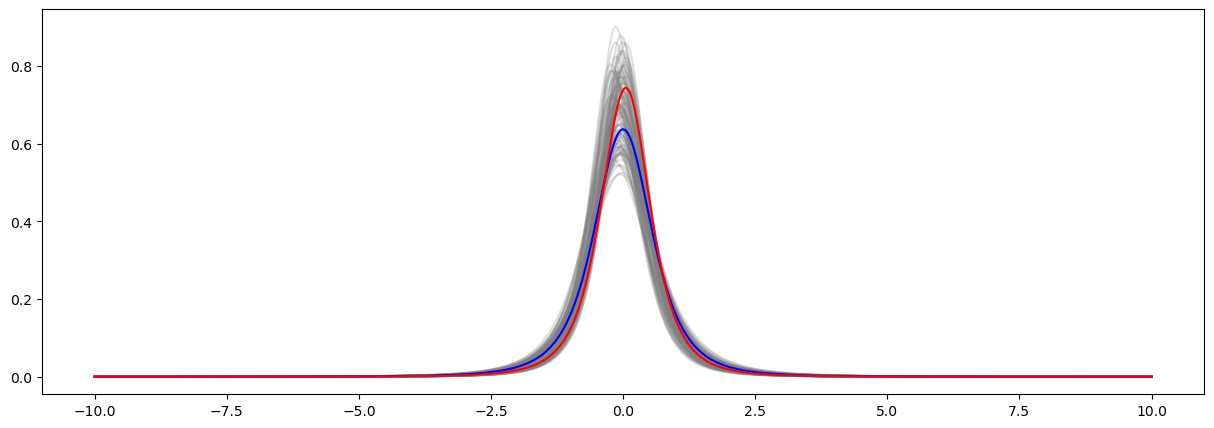

In [ ]:
simulations_database["scenario_3___nu=3"]["replications"][0]["densities"].plot(color="gray", alpha=.25, legend=False, figsize=(15,5))
simulations_database["scenario_3___nu=3"]["replications"][0]["densities"].iloc[:,0].plot(color="blue", legend=False, figsize=(15,5))
simulations_database["scenario_3___nu=3"]["replications"][0]["densities"].iloc[:,-1].plot(color="red", legend=False, figsize=(15,5))

In [177]:
# model = 'scenario_1___nu=3'
# print(sim_database[model]["params"])
# sim_database[model][10]["densities"].iloc[:,:2].plot(figsize=(15,5))
# sim_database[model][10]["samples"].iloc[:,:2].plot(kind="hist", density=True, bins=30, figsize=(15,5), alpha=.5)

# KDEs

In [ ]:
# KDE params
# t_dfs = range(3,6)
t_dfs = [3]

rot_grid = {
    "method": ["rot"],
    "kernel": ["gaussian"],
    "sigma_robust": [False]
}

rot_grid_t = {
    "method": ["rot"],
    "kernel": ["t-student"],
    "df": [df for df in t_dfs],
    "sigma_robust": [False]
}

# adaptive_grid = {
#     "method": ["adaptive"], 
#     "kernel": ["gaussian"]
# }

# adaptive_grid_t = {
#     "method": ["adaptive"], 
#     "kernel": ["t-student"],
#     "df": [df for df in t_dfs],
# }


density_param_grid = {}
for grid in [rot_grid, rot_grid_t]:
    for params in ParameterGrid(grid):
        
        key_parts = [params["kernel"]]
        if "method" in params: key_parts.append(params["method"])
        if "df" in params: key_parts.append(f"df={params['df']}")
        if params.get("sigma_robust"): key_parts.append("robust")
        if params.get("cv") == "LOO": key_parts.append("loo")
        
        full_model_name = "_".join(key_parts).replace(".", "")
        
        kernel_label = params["kernel"]
        if "df" in params:
            kernel_label += f"+df={params['df']}"
            
        bw_label = params.get("method", "fixed")
        if params.get("sigma_robust"): bw_label += "_robust"
        if params.get("cv") == "LOO": bw_label += "_loo"


        density_param_grid[full_model_name] = {
            "kernel": kernel_label,
            "bandwidth": bw_label,
            "params": params  
        }

print("KDE models:")
for name, values in density_param_grid.items():
    print("\t",name, ":", values["params"])

print(f"Total KDE models: {len(density_param_grid.items())}")

KDE models:
	 gaussian_rot : {'kernel': 'gaussian', 'method': 'rot', 'sigma_robust': False}
	 t-student_rot_df=3 : {'df': 3, 'kernel': 't-student', 'method': 'rot', 'sigma_robust': False}
Total KDE models: 2


In [ ]:
total = len(sim_database) * N_REPS * len(density_param_grid)
pbar = tqdm(total=total, desc="Total CV Progress")

kde_databases = {}
# progress = 0
for scenario, database in sim_database.items():
    print(f"Processing configuration for {database['params']}")
    kde_databases[scenario] = {}
    sim_reps_database = sim_database[scenario]["replications"]
    
    for n_rep, df in sim_reps_database.items():
        print(f"\t{n_rep}")
        returns_df = sim_reps_database[n_rep]['samples']
        kde_databases[scenario][n_rep] = {}
        
        for kde_bw_name, kde_bw_params in density_param_grid.items():
            print(f"\t simulation n. = {n_rep}: {kde_bw_name}")
            
            # bandwidths
            df_h = kde.df_bandwidth_selector(returns_df, **kde_bw_params["params"])    
            kde_params = {k: v for k, v in kde_bw_params["params"].items() if k in ['kernel', 'df']}
            
            # kdes
            df_grids, df_densities = kde.df_to_kde(
                X=returns_df, 
                h=df_h, 
                normalize_densities=False,
                **kde_params
            )

            rep_result = {
                        "scenario":     scenario,
                        "n_rep":        n_rep,
                        "model_name":   kde_bw_name,
                        "kde_params":   kde_bw_params["kernel"],
                        "kernel":       kde_bw_params["params"]["kernel"],
                        "bw_params":    kde_bw_params["bandwidth"],
                        "bw_method":    kde_bw_params["params"]["method"],
                        "df_h":         df_h,
                        "df_support":   df_grids,
                        "df_densities": df_densities
                }

            # kde_databases[scenario][n_rep][kde_bw_name] = rep_result
            
            joblib.dump(rep_result, f"{CV_FILES_PATH}{scenario}___rep_{n_rep}___kde_{kde_bw_name}.jbl")

            del df_h
            del df_grids
            del df_densities
            del kde_params

            # progress += 1
            # print(f"{progress}/{total}")
            pbar.update(1)


Total CV Progress:   0%|          | 0/2000 [00:00<?, ?it/s]

Processing configuration for {'scenario': 'scenario_2___nu=3', 'nu': 3, 'alpha': array([[0.01, 0.  , 0.  ],
       [0.  , 0.08, 0.  ],
       [0.  , 0.  , 0.01]]), 'beta': array([[0.95, 0.  , 0.  ],
       [0.  , 0.9 , 0.  ],
       [0.  , 0.  , 0.95]])}
	0
	 simulation n. = 0: gaussian_rot
	 simulation n. = 0: t-student_rot_df=3
	1
	 simulation n. = 1: gaussian_rot
	 simulation n. = 1: t-student_rot_df=3
	2
	 simulation n. = 2: gaussian_rot
	 simulation n. = 2: t-student_rot_df=3
	3
	 simulation n. = 3: gaussian_rot
	 simulation n. = 3: t-student_rot_df=3
	4
	 simulation n. = 4: gaussian_rot
	 simulation n. = 4: t-student_rot_df=3
	5
	 simulation n. = 5: gaussian_rot
	 simulation n. = 5: t-student_rot_df=3
	6
	 simulation n. = 6: gaussian_rot
	 simulation n. = 6: t-student_rot_df=3
	7
	 simulation n. = 7: gaussian_rot
	 simulation n. = 7: t-student_rot_df=3
	8
	 simulation n. = 8: gaussian_rot
	 simulation n. = 8: t-student_rot_df=3
	9
	 simulation n. = 9: gaussian_rot
	 simulation n.

In [ ]:
# kdes_paths = [''.join([CV_FILES_PATH, x]) for x in os.listdir(CV_FILES_PATH) if "scenario" in x]
kde_jbls_path = CV_FILES_PATH
kdes_paths = [''.join([kde_jbls_path, x]) for x in os.listdir(kde_jbls_path)]

kde_addresses = []
for path_name in kdes_paths:
    obj = joblib.load(path_name)
    kde_address = {
        "scenario":   obj["scenario"],
        "n_rep":      obj["n_rep"],
        "model_name": obj["model_name"],
        "address":    path_name
    }
    kde_addresses.append(kde_address)

kde_addresses = sorted(
    kde_addresses,
    key=lambda x: (x["scenario"], x["n_rep"], x["model_name"])
)

kde_index = {
    (d["scenario"], d["n_rep"], d["model_name"]): d["address"]
    for d in kde_addresses
}

# $Y_t=\Lambda(\hat{f_t})$

In [ ]:
n_kde_addresses = len(kde_addresses)
pbar = tqdm(total=n_kde_addresses, desc="Total LQD(fhat) Progress")

for kde in kde_addresses:
    scenario_kde_dict = joblib.load(kde["address"])
    id_scenario_kde     = scenario_kde_dict["scenario"]
    n_rep               = scenario_kde_dict["n_rep"]
    model_name_path     = scenario_kde_dict['model_name']
    model_name          = scenario_kde_dict['model_name'].replace("_", " ")
    # carregar KDE
    # transformar para L2
    # salvar

    mlqdt = lqdt.mLQDT()
    model_lqd = mlqdt.transform(
        densities=scenario_kde_dict["df_densities"],
        densities_supports=scenario_kde_dict["df_support"], 
        verbose=False
        )
    # model_lqd.densities_to_lqdensities(verbose=False)
    
    # 2. L2 Expansion (K_dFPC)
    Y_t  = model_lqd.lqd.copy()
    Y_t.index = model_lqd.lqd_support
    
    # KdFPC_kwargs.update({
    #     "u": lqd_support,
    #     "du": model_lqd.du
    # })
    
    # model_kdfpc = dfpc.K_dFPC(lqd_values)
    # model_kdfpc.fit(**KdFPC_kwargs)

    # Y_t = pd.DataFrame(model_kdfpc.Y)
    # Y_t.columns = df_densities.columns
    # Y_t.index   = model_lqd.lqd_support

    kde_mlqdt_result = {
                "scenario":     kde["scenario"],
                "n_rep":        kde["n_rep"],
                "model_name":   kde["model_name"],
                "kde_mlqdt":    Y_t
        }
    
    joblib.dump(kde_mlqdt_result, f"{KDE_LQD_PATH}lqd___scenario_{id_scenario_kde}___rep_{n_rep}___kde_{model_name_path}.jbl")

    pbar.update(1)

Total LQD(fhat) Progress:   0%|          | 0/2000 [00:00<?, ?it/s]

/opt/anaconda3/envs/densities4risk/lib/python3.11/site-packages/scipy/interpolate/_interpolate.py:501: RuntimeWarning: overflow encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
/opt/anaconda3/envs/densities4risk/lib/python3.11/site-packages/scipy/interpolate/_interpolate.py:504: RuntimeWarning: invalid value encountered in multiply
  y_new = slope*(x_new - x_lo)[:, None] + y_lo
/opt/anaconda3/envs/densities4risk/lib/python3.11/site-packages/scipy/interpolate/_interpolate.py:501: RuntimeWarning: divide by zero encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]


In [ ]:
# kdes_lqd_paths = [''.join([KDE_LQD_PATH, x]) for x in os.listdir(KDE_LQD_PATH) if "scenario" in x]
kdes_lqd_paths = [''.join([KDE_LQD_PATH, x]) for x in os.listdir(KDE_LQD_PATH)]


kdes_lqd_addresses = []
for path_name in kdes_lqd_paths:
    obj = joblib.load(path_name)
    kde_address = {
        "scenario":   obj["scenario"],
        "n_rep":      obj["n_rep"],
        "model_name": obj["model_name"],
        "address":    path_name
    }
    kdes_lqd_addresses.append(kde_address)

kde_lqd_index = {
    (d["scenario"], d["n_rep"], d["model_name"]): d["address"]
    for d in kdes_lqd_addresses
}

# Cross-validation

In [ ]:
# 1. Setup Logger
logger = logging.getLogger("Density_Estimation")
logger.setLevel(logging.DEBUG)

# 2. Setup File Handler
file_handler = logging.FileHandler(LOG_PATH)
file_handler.setFormatter(logging.Formatter('%(asctime)s | %(levelname)s | %(message)s'))
logger.addHandler(file_handler)

# 3. CAPTURE WARNINGS: This handles "Forecast with mean" style warnings
logging.captureWarnings(True)

In [ ]:
KdFPC_kwargs = {
    "p": 5,
    "select_ncomp": "variance",
    # "dimension": 3
}

In [ ]:
initial_window = 99
horizon = 1

total_models = len(kde_addresses)
pbar = tqdm(total=total_models, desc="Total CV Progress")

logger.info("\nInitiating cross validation...")
for kde_address in kde_addresses:
    print(kde_address)
    scenario_kde_dict = joblib.load(kde_address["address"])

    # KDE database
    id_scenario_kde     = scenario_kde_dict["scenario"]
    sim_info            = simulations_database[id_scenario_kde]["params"]
    n_rep               = scenario_kde_dict["n_rep"]
    model_name_path     = scenario_kde_dict['model_name']
    model_name          = scenario_kde_dict['model_name'].replace("_", " ")
    logger.info(
            f"Scenario: {id_scenario_kde} | n_rep: {n_rep} | KDE model: {model_name}"
            )

    df_support, df_densities = scenario_kde_dict["df_support"], scenario_kde_dict["df_densities"]

    # Simulations database
    sim_densities         = simulations_database[id_scenario_kde]["replications"][n_rep]["densities"]
    sim_densities_supp    = sim_densities.copy()
    sim_densities_supp.loc[:,:] = sim_densities_supp.index.to_numpy()[:, None]


    # L2 database
    kde_lqd_address       = kde_lqd_index.get((id_scenario_kde, n_rep, scenario_kde_dict['model_name']))
    scenario_kde_lqd      = joblib.load(kde_lqd_address)["kde_mlqdt"]
    scenario_kde_lqd_supp = scenario_kde_lqd.copy()
    scenario_kde_lqd_supp.loc[:,:] = scenario_kde_lqd_supp.index.to_numpy()[:, None]
    
    # Cross-validation
    windows = crossVal.expanding_window_cv(df_densities.shape[1], h=horizon, initial_window=initial_window)
#     curves_hist = []
    measures = []
    for fold, window in enumerate(windows):
            fold += 1
            print(f"\t\t>>> cv {fold}/{len(windows)}")
            idx_train      = window[0]
            idx_test       = window[1]
            test_date      = df_densities.columns[idx_test]
            
            #------------ target variables ------------#
            Y_t_support, Y_t                   = scenario_kde_lqd_supp.loc[:, test_date], scenario_kde_lqd.loc[:, test_date]
            # lambda(f_{n+1})
            # X_boot
            f_hat_t_supp, f_hat_t = df_support.loc[:, test_date], df_densities.loc[:, test_date]
            f_t_support,  f_t     = sim_densities_supp.loc[:, test_date], sim_densities.loc[:, test_date]
            # lambda^{-1}(X_boot)
            #-----------------------------------------#

            # Train-test split
            kde_train_support, kde_train = df_support.iloc[:,idx_train], df_densities.iloc[:,idx_train]
            
            # Forecasting
            forecaster = fp.DensityForecaster(kdfpc_kwargs=KdFPC_kwargs, maxlags=10)
            forecaster.fit(kde_train, kde_train_support)
            mdfpc_fc = forecaster.predict(horizon=1, var_lags=None, forecast_index=test_date)

            # Predictions
            Y_hat_t = mdfpc_fc["future_L2_curves"]

            lambda_inv_Y_hat_t_supp=  mdfpc_fc["future_supports"]
            lambda_inv_Y_hat_t =      mdfpc_fc["future_densities"]

            #------------ common grid ------------#
            # \hat{Y}_{n+1} x  Y_{n+1}
            acc_measures = acc.overall_measures(forecast=Y_hat_t, test=Y_t)
            temp_df = pd.DataFrame({
                    "support":  Y_t.index,
                    "actual":   Y_t.iloc[:, 0].values,
                    "forecast": Y_hat_t.iloc[:, 0].values,
                    "date":     test_date[0],
                    "fold":     fold
                    }).set_index(["fold", "date", "support"])
            measures.append({
                    "scenario":   id_scenario_kde,
                    "n_rep":      n_rep,
                    "model_name": model_name,
                    "fold":       fold,
                    "comparison": "yHatFc_Y",
                    "fc_date":    test_date[0],
                    **acc_measures,
                    "curves":     temp_df
            })
            # \Lambda^{-1}(\hat{Y}_{n+1}) x  \hat{f}_{n+1}
            df_supp, df_kde, df_fc = fdaUtils.align_densities(
                                            f_hat_t_supp, 
                                            f_hat_t, 
                                            lambda_inv_Y_hat_t_supp, 
                                            lambda_inv_Y_hat_t, 
                                            lambda_inv_Y_hat_t.columns
                                            )
            acc_measures = acc.overall_measures(forecast=df_fc, test=df_kde)
            temp_df = pd.DataFrame({
                    "support":  df_support.iloc[:,0].values,
                    "actual":   df_kde.iloc[:, 0].values,
                    "forecast": df_fc.iloc[:, 0].values,
                    "date":     test_date[0],
                    "fold":     fold
                    }).set_index(["fold", "date", "support"])
            measures.append({
                    "scenario":   id_scenario_kde,
                    "n_rep":      n_rep,
                    "model_name": model_name,
                    "fold":       fold,
                    "comparison": "fHatFc_fHat",
                    "fc_date":    test_date[0],
                    **acc_measures,
                    "curves":     temp_df
            })
            # \Lambda^{-1}(\hat{Y}_{n+1}) x  f_{n+1}
            df_supp, df_kde, df_fc = fdaUtils.align_densities(
                                            f_t_support, 
                                            f_t, 
                                            lambda_inv_Y_hat_t_supp, 
                                            lambda_inv_Y_hat_t, 
                                            lambda_inv_Y_hat_t.columns
                                            )
            acc_measures = acc.overall_measures(forecast=df_fc, test=df_kde)
            temp_df = pd.DataFrame({
                    "support":  df_support.iloc[:,0].values,
                    "actual":   df_kde.iloc[:, 0].values,
                    "forecast": df_fc.iloc[:, 0].values,
                    "date":     test_date[0],
                    "fold":     fold
                    }).set_index(["fold", "date", "support"])
            measures.append({
                    "scenario":   id_scenario_kde,
                    "n_rep":      n_rep,
                    "model_name": model_name,
                    "fold": fold,
                    "comparison": "fHatFc_f",
                    "fc_date":    test_date[0],
                    **acc_measures,
                    "curves":     temp_df
            })
    joblib.dump(measures, f"{CV_FC_PATH}cvFc___scenario_{id_scenario_kde}___rep_{n_rep}___kde_{model_name_path}.jbl")
    pbar.update(1)

Total CV Progress:   0%|          | 0/2000 [00:00<?, ?it/s]

{'scenario': 'scenario_2___nu=3', 'n_rep': 0, 'model_name': 'gaussian_rot', 'address': '../data/interim/simulation/20260503/progress/scenario_2___nu=3___rep_0___kde_gaussian_rot.jbl'}
		>>> cv 1/1
{'scenario': 'scenario_2___nu=3', 'n_rep': 0, 'model_name': 't-student_rot_df=3', 'address': '../data/interim/simulation/20260503/progress/scenario_2___nu=3___rep_0___kde_t-student_rot_df=3.jbl'}
		>>> cv 1/1
{'scenario': 'scenario_2___nu=3', 'n_rep': 1, 'model_name': 'gaussian_rot', 'address': '../data/interim/simulation/20260503/progress/scenario_2___nu=3___rep_1___kde_gaussian_rot.jbl'}
		>>> cv 1/1
{'scenario': 'scenario_2___nu=3', 'n_rep': 1, 'model_name': 't-student_rot_df=3', 'address': '../data/interim/simulation/20260503/progress/scenario_2___nu=3___rep_1___kde_t-student_rot_df=3.jbl'}
		>>> cv 1/1
{'scenario': 'scenario_2___nu=3', 'n_rep': 2, 'model_name': 'gaussian_rot', 'address': '../data/interim/simulation/20260503/progress/scenario_2___nu=3___rep_2___kde_gaussian_rot.jbl'}
		>>

# Results

In [5]:
cv_results = []
cv_files = [''.join([CV_FC_PATH,x]) for x in os.listdir(CV_FC_PATH)]
for file in cv_files:
    cv_results.append(pd.DataFrame(joblib.load(file)))
df_cv_results = pd.concat(cv_results)
df_cv_results.sort_values(by=["scenario", "n_rep", "model_name"], inplace=True)
df_cv_results.reset_index(inplace=True, drop=True)

In [22]:
df_cv_results.comparison.unique()

<ArrowStringArray>
['yHatFc_Y', 'fHatFc_fHat', 'fHatFc_f']
Length: 3, dtype: str

In [23]:
# df_cv_results.reset_index(inplace=True, drop=True)
# comparison = 'fHatFc_fHat'
# df_cv_results = df_cv_results[df_cv_results["comparison"]== comparison]

In [25]:
df_cv_results.groupby("model_name")["KLD"].mean().sort_values()

model_name
t-student rot df=3    0.071226
gaussian rot          0.104801
Name: KLD, dtype: float64

In [26]:
# Extract the first two parts only
split_data = df_cv_results['scenario'].str.split("___", expand=True)
df_cv_results["scenario_id"] = split_data[0]
df_cv_results["t_df"] = split_data[1]

df_cv_results.groupby(["scenario_id", "t_df", "comparison", "model_name"], as_index=False)[["KLD", "L_1", "L_2", "L_INFTY"]].mean().sort_values(by=["scenario_id", "comparison", "t_df", "KLD"])

,scenario_id,t_df,comparison,model_name,KLD,L_1,L_2,L_INFTY
0,scenario_2,nu=3,fHatFc_f,gaussian rot,0.134288,38.782168,1.549847,0.172755
1,scenario_2,nu=3,fHatFc_f,t-student rot df=3,0.140856,50.399788,1.832576,0.145292
7,scenario_2,nu=8,fHatFc_f,t-student rot df=3,0.083479,35.033390,1.076169,0.066061
6,scenario_2,nu=8,fHatFc_f,gaussian rot,0.086487,28.452105,1.048042,0.127562
3,scenario_2,nu=3,fHatFc_fHat,t-student rot df=3,0.105330,14.282919,0.667428,0.068746
2,scenario_2,nu=3,fHatFc_fHat,gaussian rot,0.180146,15.559095,0.816723,0.128381
9,scenario_2,nu=8,fHatFc_fHat,t-student rot df=3,0.075023,35.865643,0.960747,0.051282
8,scenario_2,nu=8,fHatFc_fHat,gaussian rot,0.128610,41.291487,1.333110,0.134970
5,scenario_2,nu=3,yHatFc_Y,t-student rot df=3,0.015037,719.089344,13.409411,2.049836
4,scenario_2,nu=3,yHatFc_Y,gaussian rot,0.074059,855.005258,121.455284,117.644092


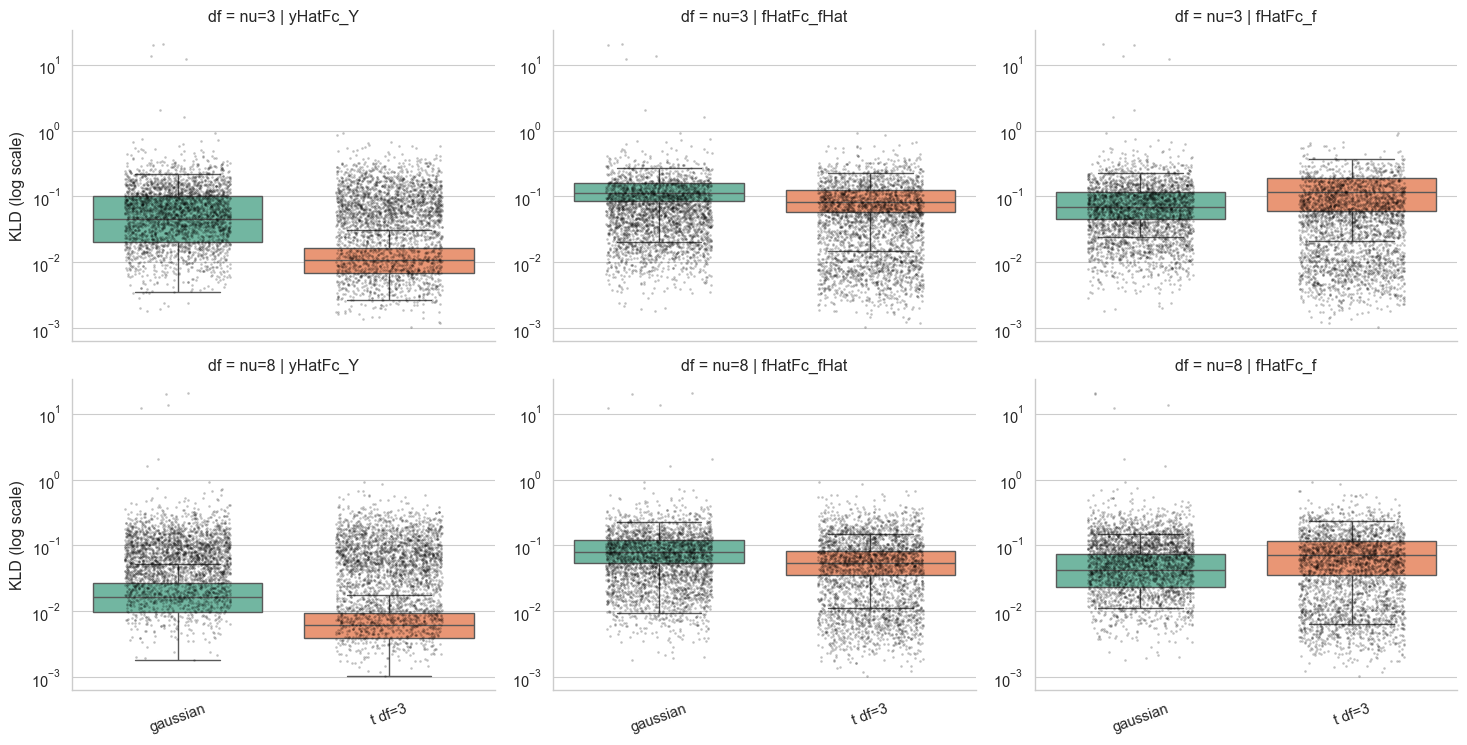

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

df_plot = df_cv_results.copy()

# Clean labels
df_plot["model_name"] = (
    df_plot["model_name"]
    .str.replace(" rot", "", regex=False)
    .str.replace("t-student", "t", regex=False)
)

# Better style
sns.set_theme(
    style="whitegrid",
    context="paper",   # cleaner than "talk" for dense plots
    font_scale=1.2
)

g = sns.catplot(
    data=df_plot,
    kind="box",
    x="model_name",
    y="KLD",
    col="comparison",
    row="t_df",
    sharey=False,
    height=3.8,
    aspect=1.3,
    linewidth=1,
    fliersize=0,   # 🔥 remove outliers from boxplot
    palette="Set2"
)

# Overlay points (controlled)
for ax in g.axes.flat:
    sns.stripplot(
        data=df_plot,
        x="model_name",
        y="KLD",
        ax=ax,
        color="black",
        size=1.8,
        alpha=0.25,
        jitter=0.25
    )

# Log scale (CRUCIAL here)
for ax in g.axes.flat:
    ax.set_yscale("log")

# Titles (cleaner)
g.set_titles(
    row_template="df = {row_name}",
    col_template="{col_name}"
)

g.set_axis_labels("", "KLD (log scale)")

# Rotate nicely
for ax in g.axes.flat:
    ax.tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

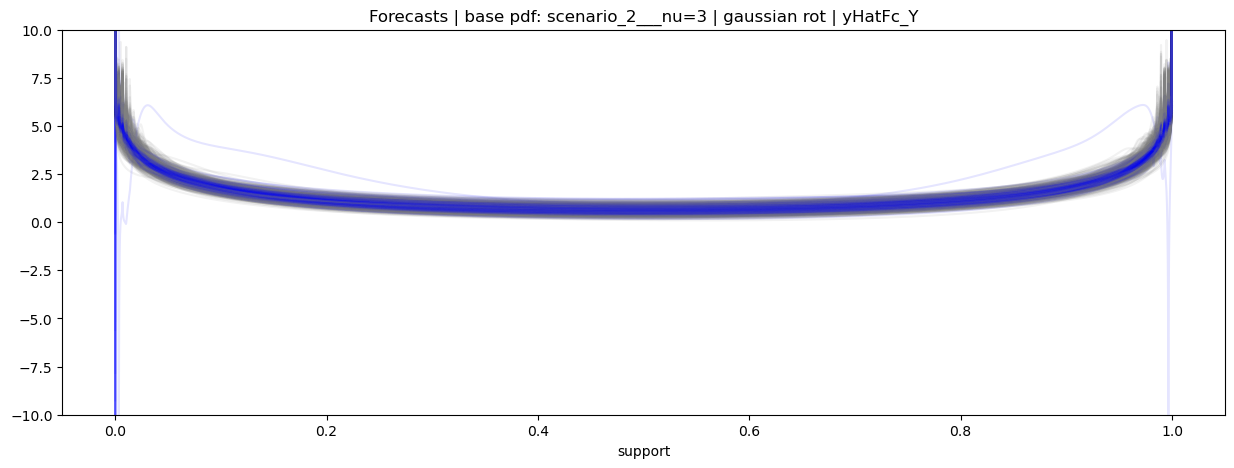

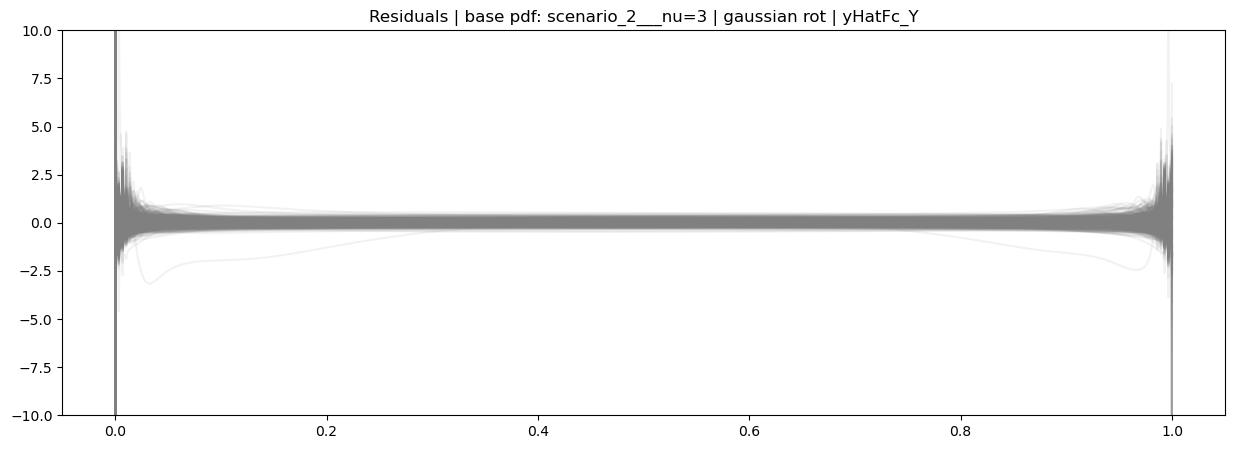

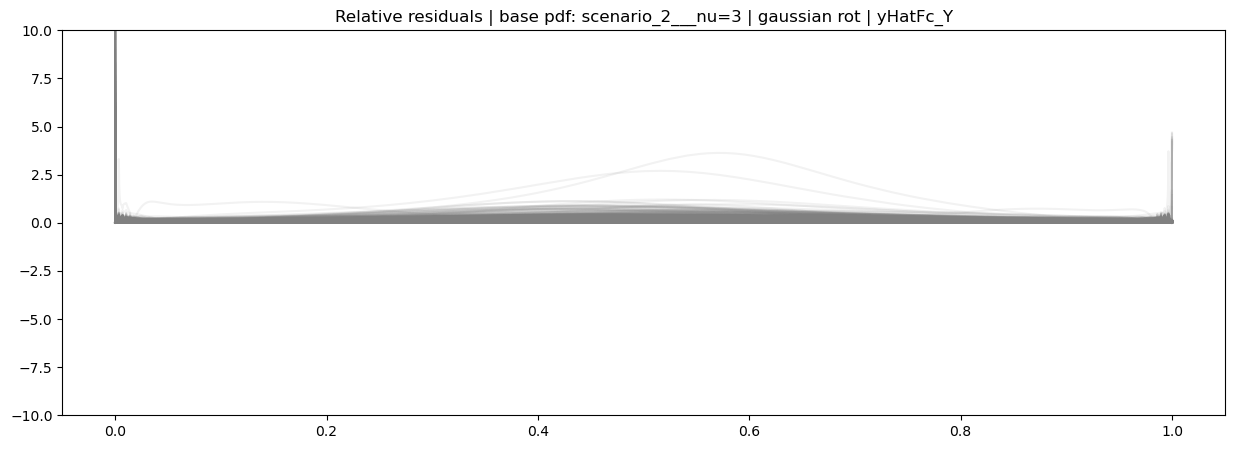

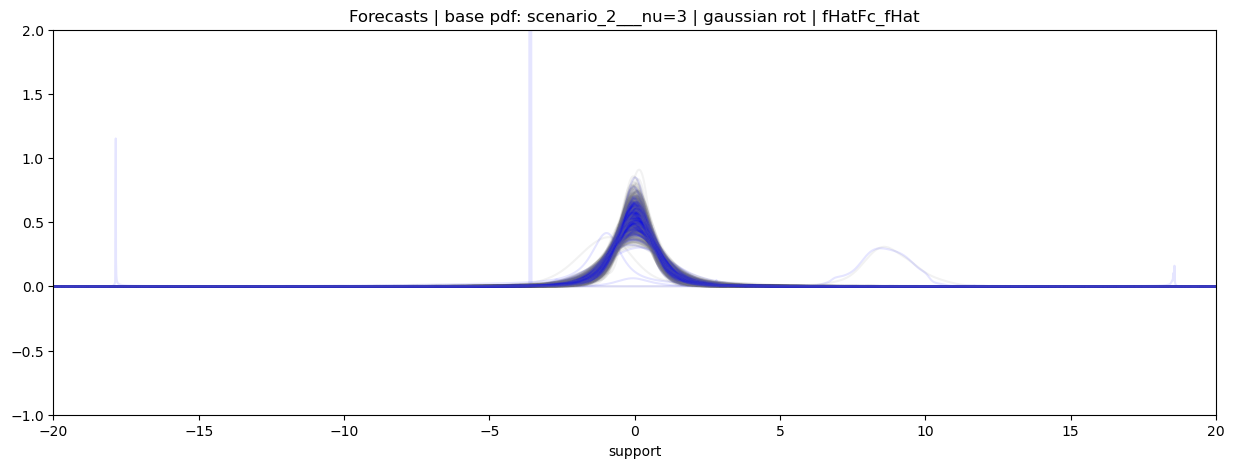

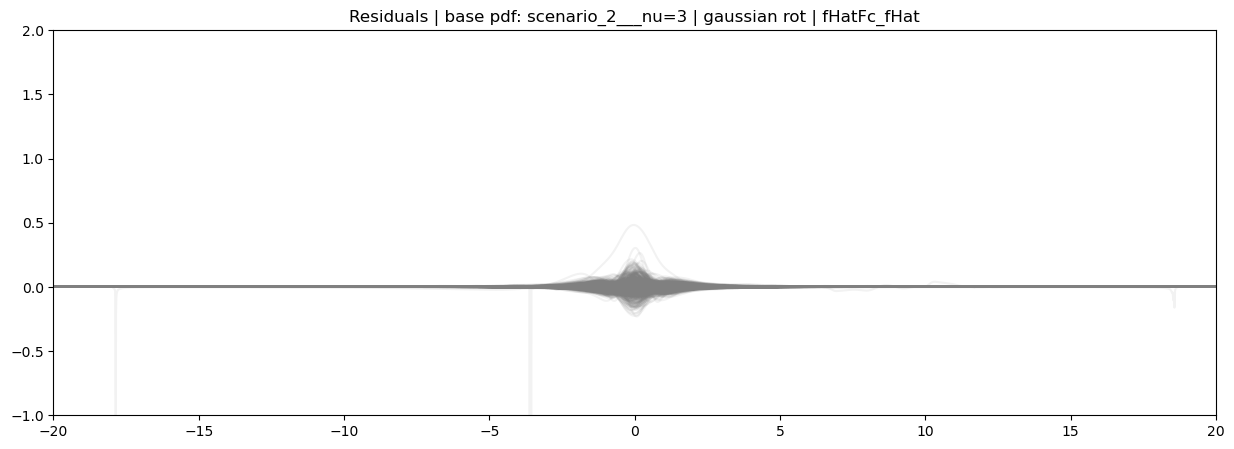

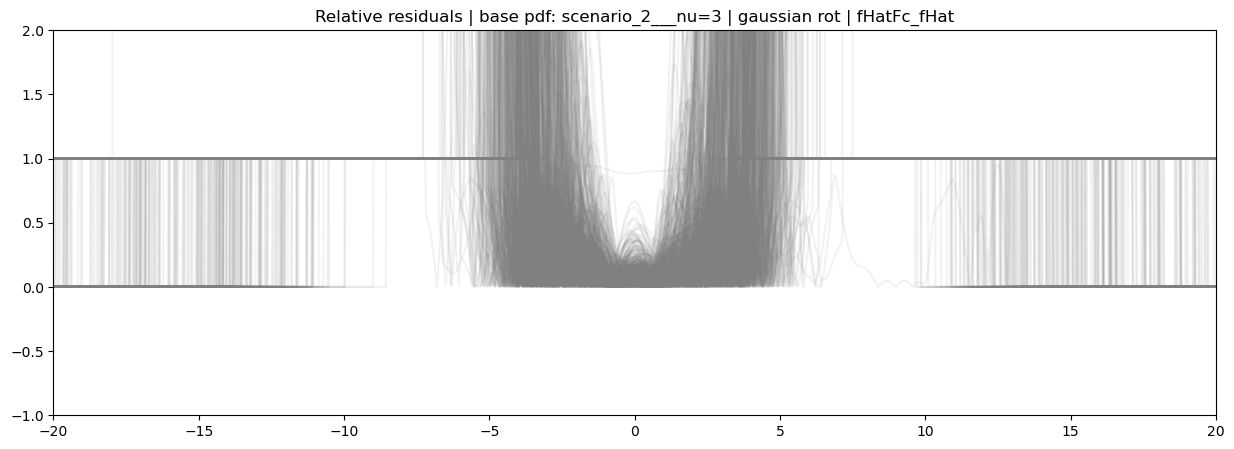

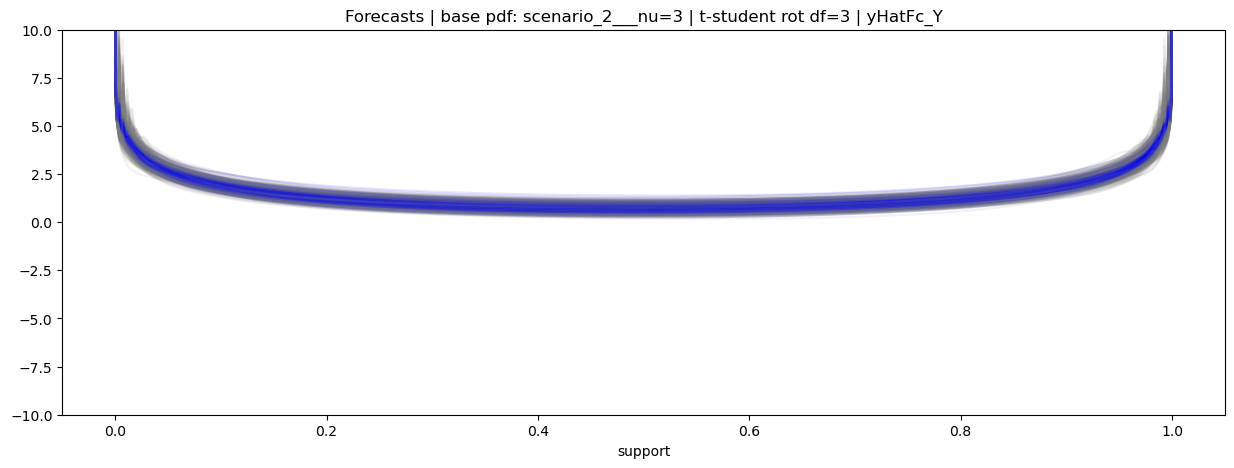

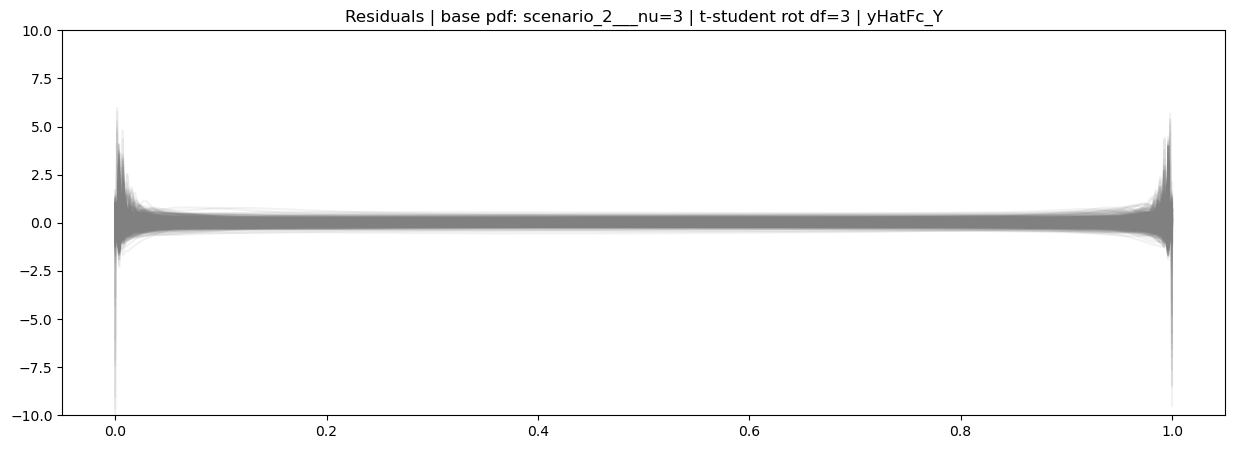

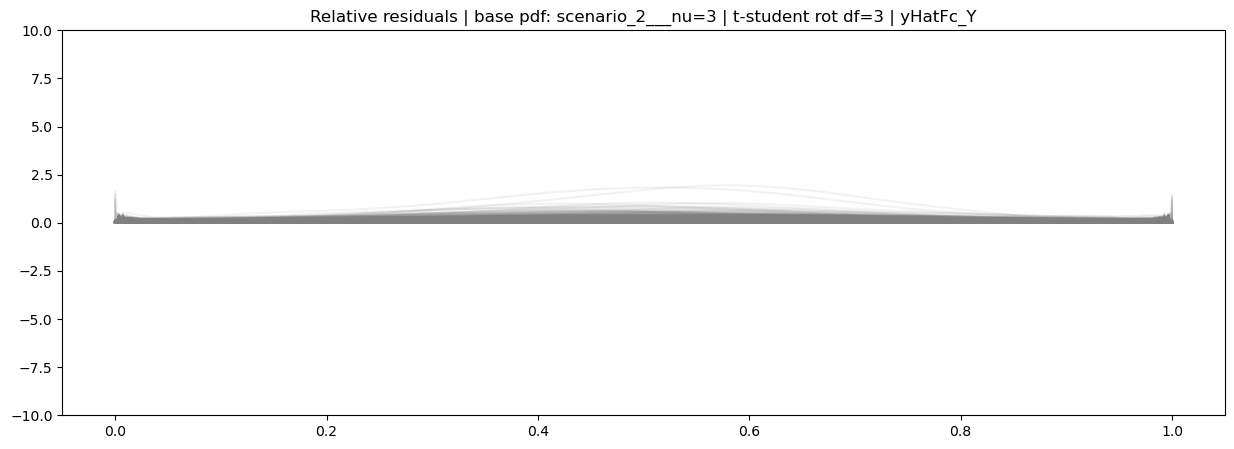

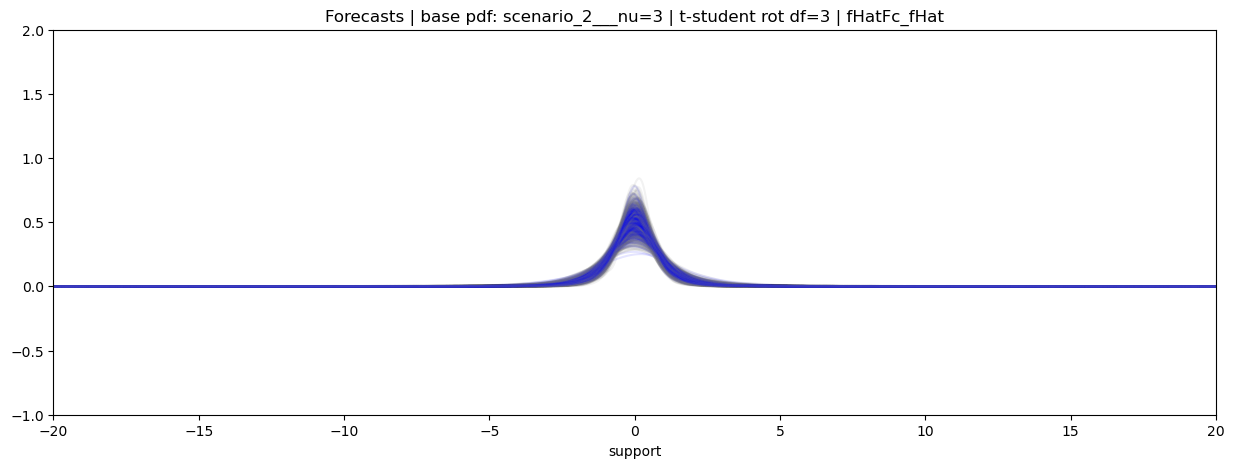

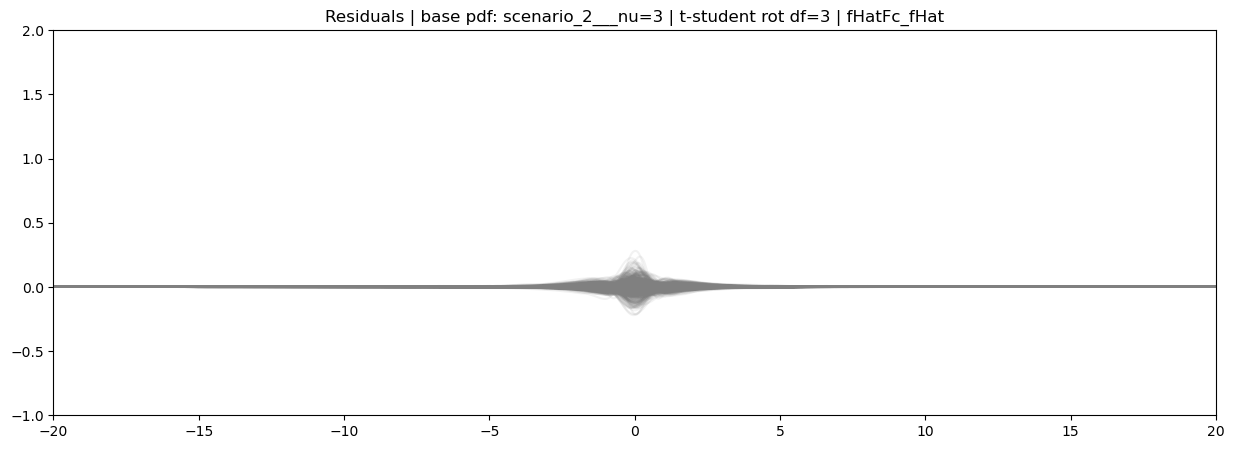

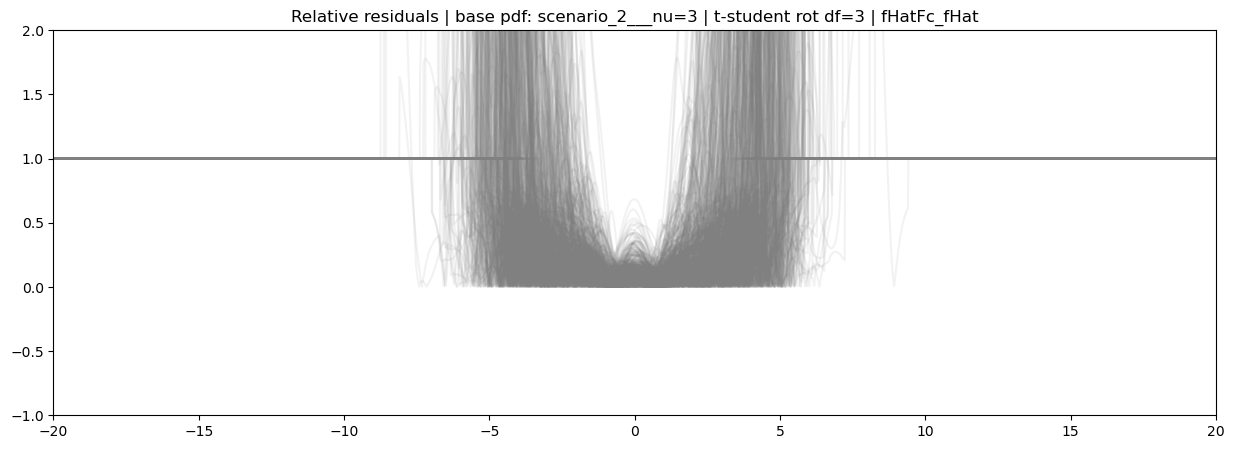

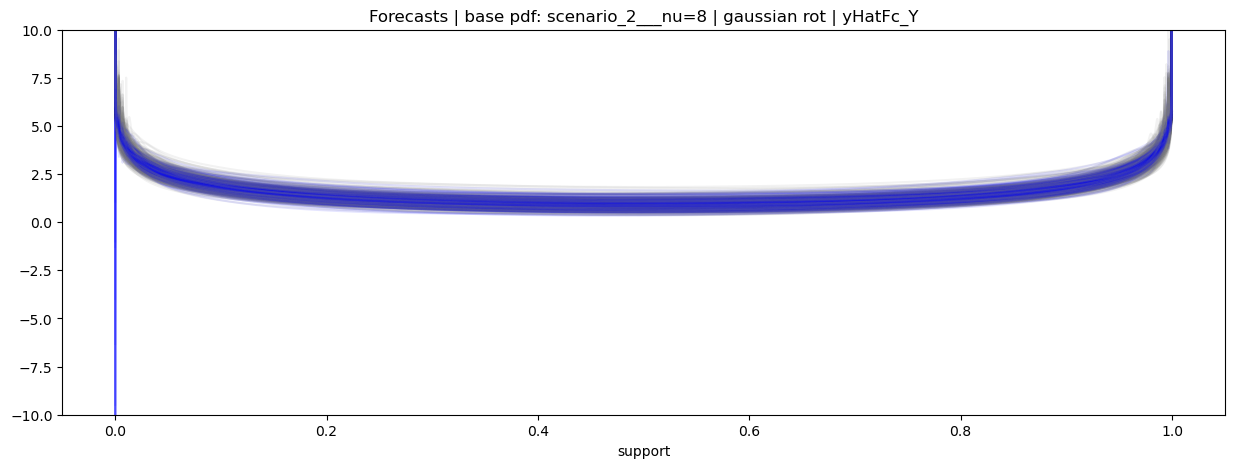

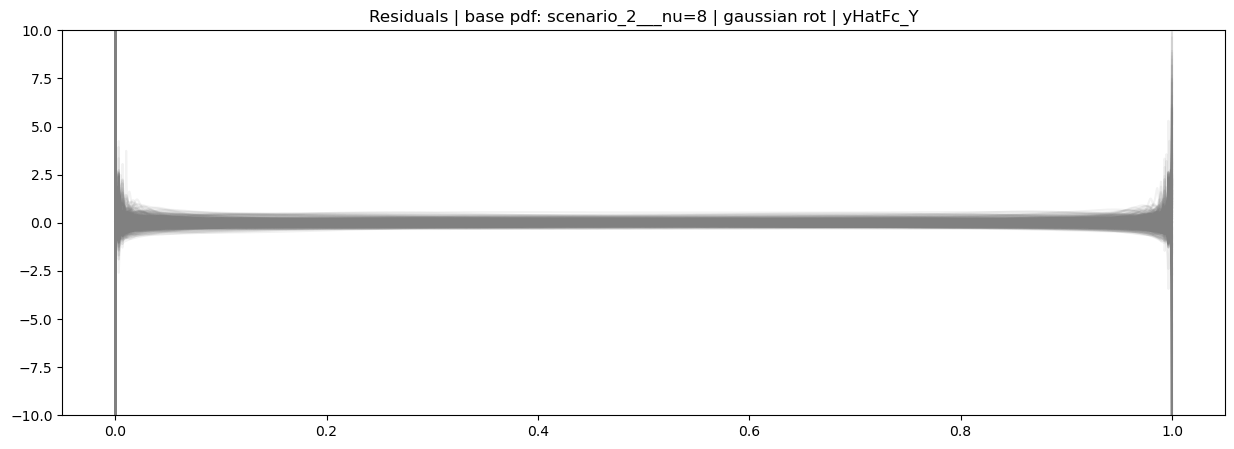

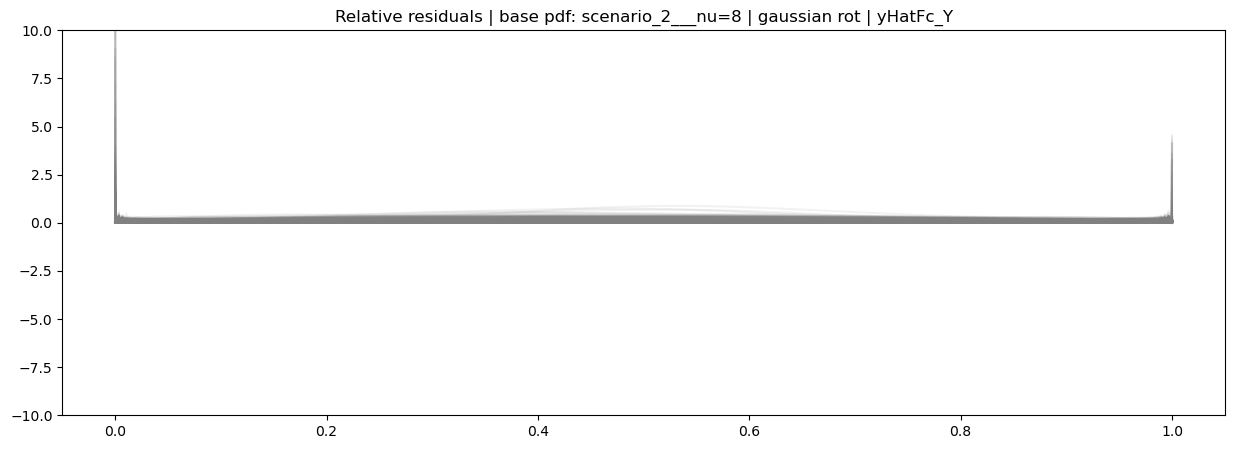

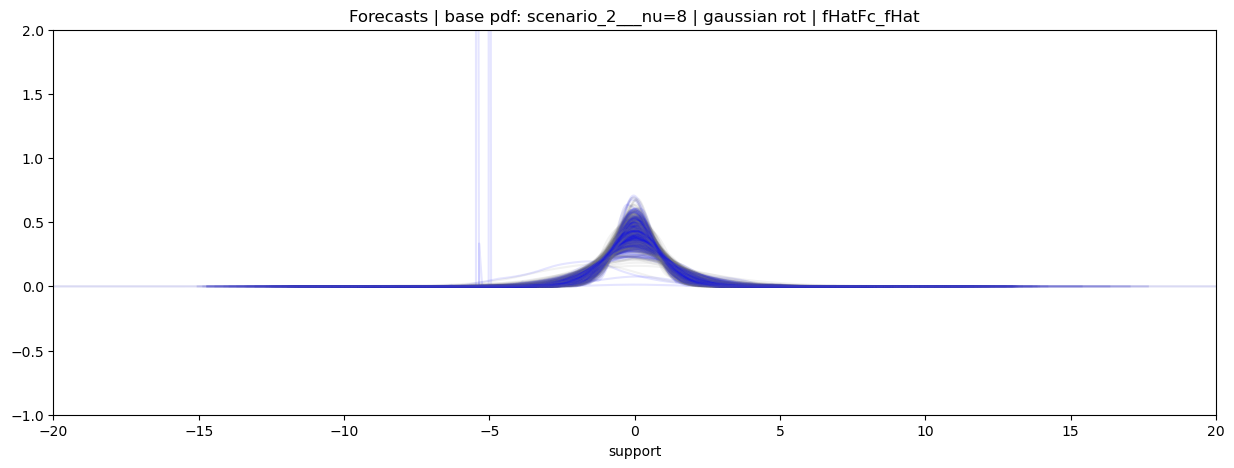

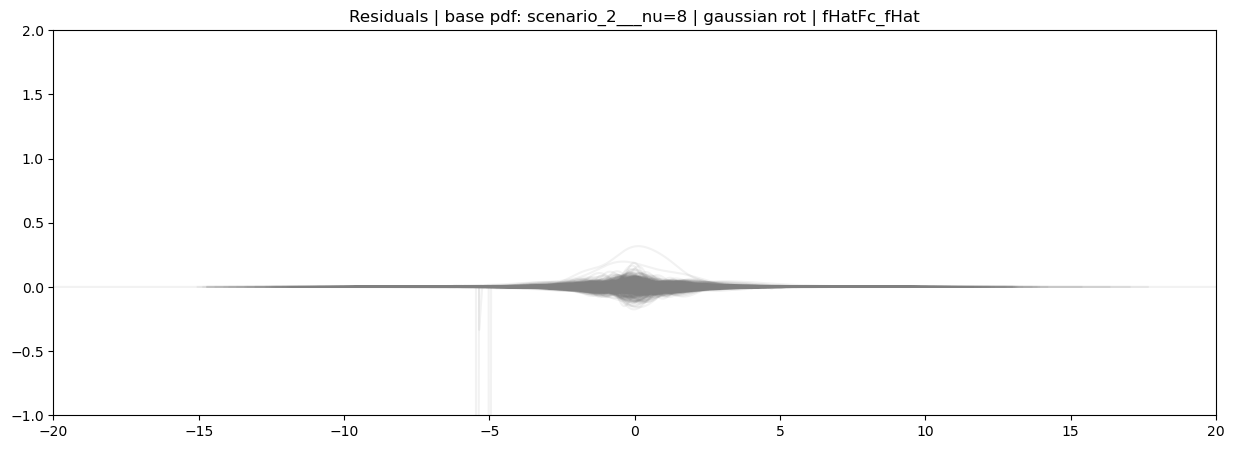

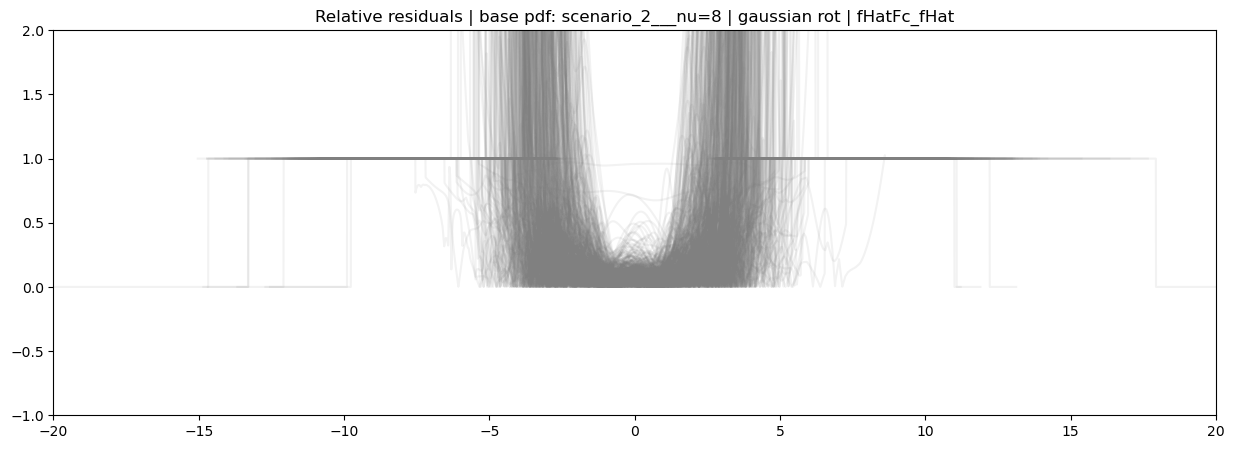

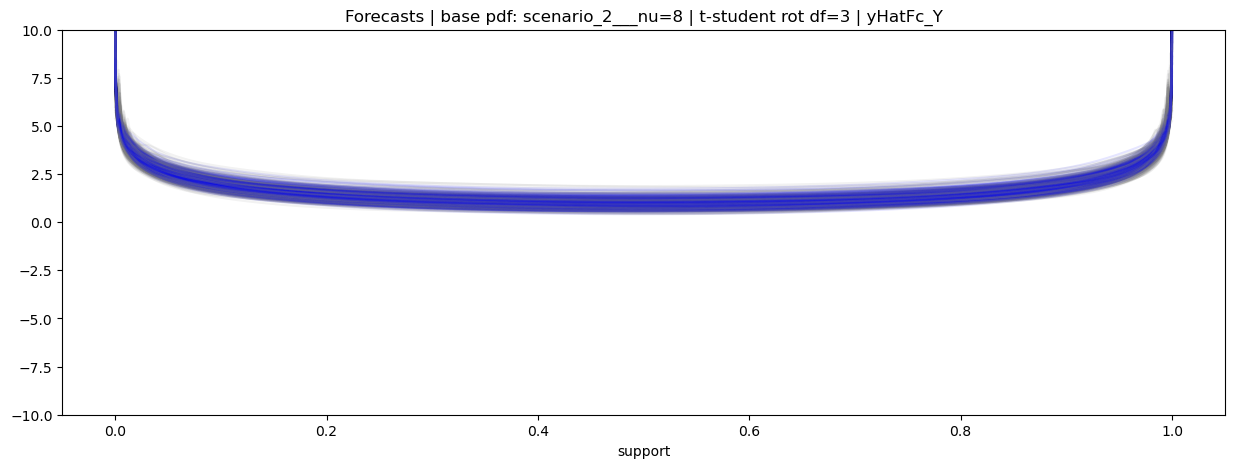

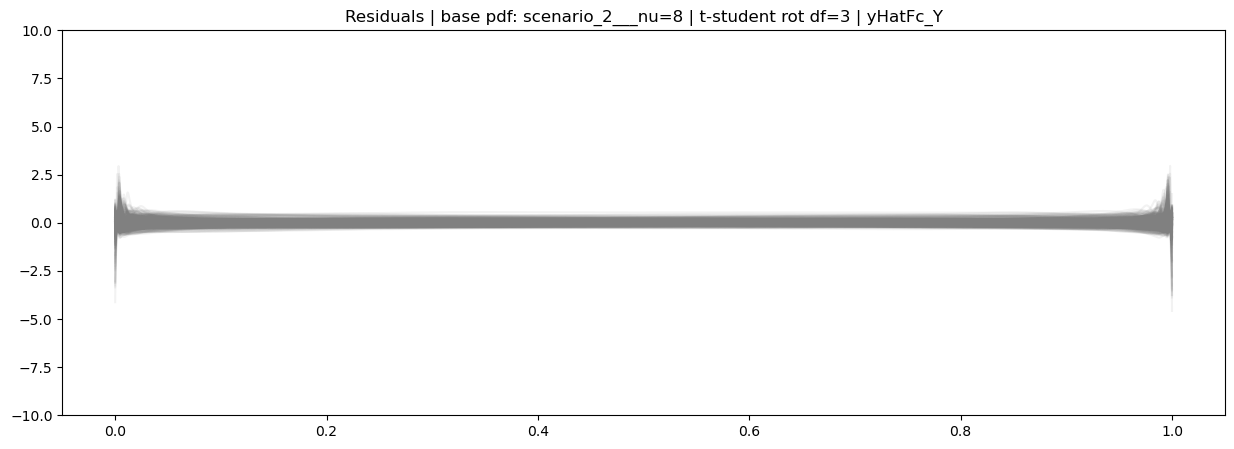

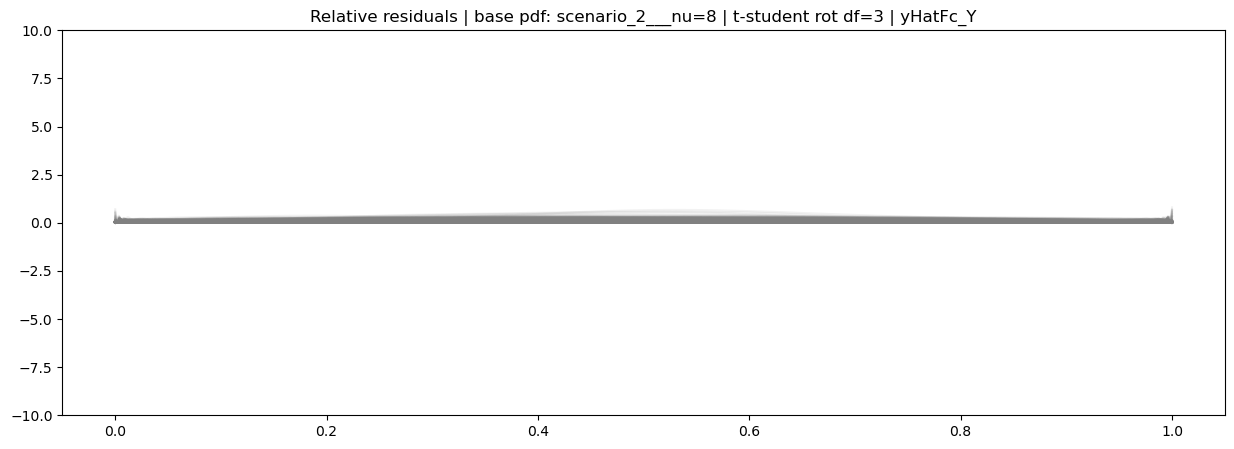

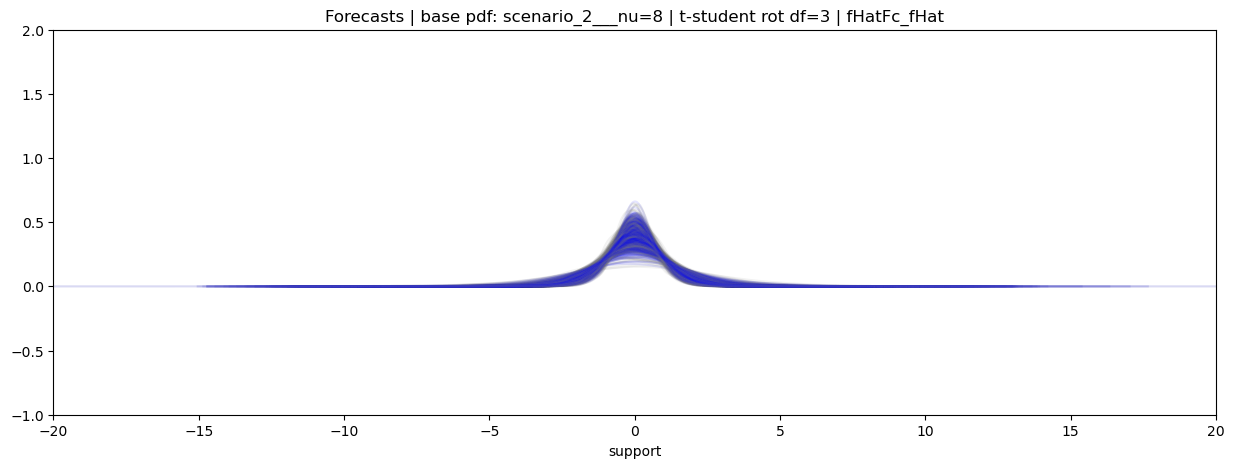

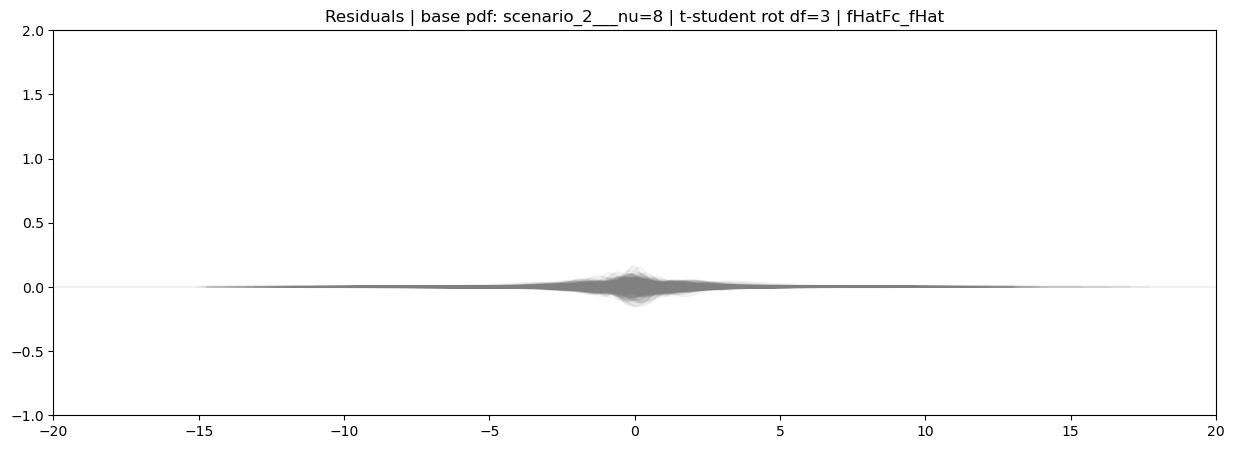

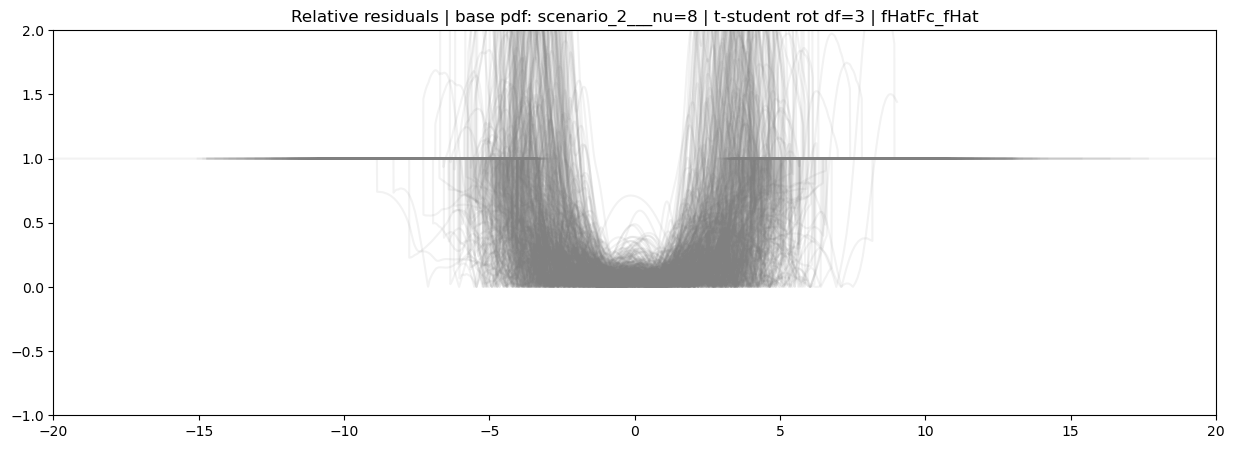

In [20]:
for scenario in df_cv_results.scenario.unique():
    df_cv_2 = df_cv_results[df_cv_results["scenario"]==scenario]
    for kde_model_name in df_cv_2.model_name.unique():
        df_cv_3 = df_cv_2[df_cv_2["model_name"]==kde_model_name]
        for target in df_cv_3.comparison.unique():
            if target.endswith("_f"):
                continue
            if "_Y" in target:
                ylim = [-10, 10]
                xlim = [-0.05, 1.05]
            else:
                ylim = [-1, 2]
                xlim = [-20, 20]
            df_cv_4 = df_cv_3[df_cv_3.comparison == target]
            plt.figure(figsize=(15,5))
            for n, x in df_cv_4.iterrows():
                curves = x["curves"].reset_index()[["support", "actual", "forecast"]].set_index("support")
                # plt.plot(curves["actual"], color="gray", alpha=0.1)
                # plt.plot(curves["forecast"], color="blue", alpha=0.1)
                curves["actual"].plot(color="gray", alpha=0.1)
                curves["forecast"].plot(color="blue", alpha=0.1)
            plt.title(f"Forecasts | base pdf: {scenario} | {kde_model_name} | {target}")
            plt.ylim(ylim)
            plt.xlim(xlim)
            plt.show()

            plt.figure(figsize=(15,5))
            for n, x in df_cv_4.iterrows():
                curves = x["curves"].reset_index()[["support", "actual", "forecast"]].set_index("support")
                curves["residuals"] = curves.actual - curves.forecast
                plt.plot(curves["residuals"], color="gray", alpha=0.1)
            plt.title(f"Residuals | base pdf: {scenario} | {kde_model_name} | {target}")
            plt.ylim(ylim)
            plt.xlim(xlim)
            plt.show()

            plt.figure(figsize=(15,5))
            for n, x in df_cv_4.iterrows():
                curves = x["curves"].reset_index()[["support", "actual", "forecast"]].set_index("support")
                curves["residuals"] = curves.actual - curves.forecast
                curves["rel_resid"] = (np.abs(curves["residuals"])/curves.actual).fillna(0)
                plt.plot(curves["rel_resid"], color="gray", alpha=0.1)
            plt.title(f"Relative residuals | base pdf: {scenario} | {kde_model_name} | {target}")
            plt.ylim(ylim)
            plt.xlim(xlim)
            plt.show()

<Axes: xlabel='fold,date,support'>

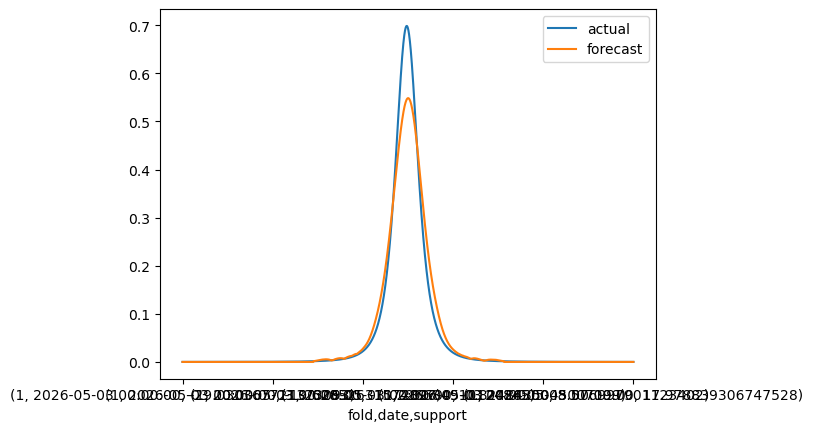

In [52]:
df_cv_results[(df_cv_results["model_name"]=="gaussian rot")&(df_cv_results["n_rep"]==18)].iloc[0,:]["curves"].plot()

In [8]:
test_path = "../data/interim/simulation/20260503/progress/scenario_2___nu=3___rep_26___kde_gaussian_rot.jbl"
test_kde = joblib.load(test_path)
test_kde_dens = test_kde["df_densities"]
test_kde_supp = test_kde["df_support"]

<Axes: >

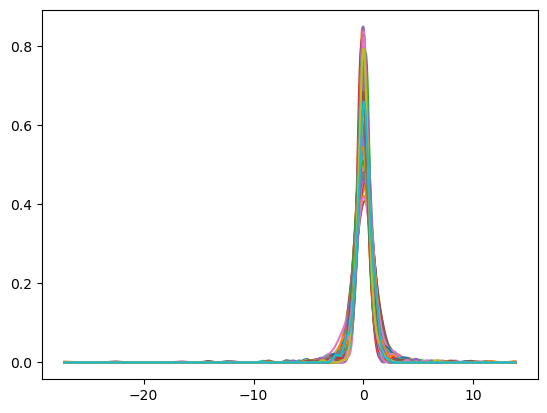

In [9]:
test_kde_dens.plot(legend=False)

In [10]:
test_kde_dens

,2026-01-24,2026-01-25,2026-01-26,2026-01-27,2026-01-28,2026-01-29,2026-01-30,2026-01-31,2026-02-01,2026-02-02,...,2026-04-24,2026-04-25,2026-04-26,2026-04-27,2026-04-28,2026-04-29,2026-04-30,2026-05-01,2026-05-02,2026-05-03
-27.195744,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.0,0.0,0.0,0.0,0.0,0.000000e+00,0.0,0.0,0.000000e+00,0.0
-27.187544,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.0,0.0,0.0,0.0,0.0,0.000000e+00,0.0,0.0,0.000000e+00,0.0
-27.179343,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.0,0.0,0.0,0.0,0.0,0.000000e+00,0.0,0.0,0.000000e+00,0.0
-27.171143,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.0,0.0,0.0,0.0,0.0,0.000000e+00,0.0,0.0,0.000000e+00,0.0
-27.162943,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.0,0.0,0.0,0.0,0.0,0.000000e+00,0.0,0.0,0.000000e+00,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13.772016,7.474877e-194,4.966353e-203,4.861168e-117,1.884739e-197,4.201458e-130,1.249894e-207,2.749456e-82,1.998389e-285,6.950928e-284,2.739989e-184,...,0.0,0.0,0.0,0.0,0.0,2.443959e-269,0.0,0.0,1.108799e-190,0.0
13.780216,3.570537e-194,2.263800e-203,2.947637e-117,9.058152e-198,2.395434e-130,5.509808e-208,1.585479e-82,7.017660e-286,2.530447e-284,1.356979e-184,...,0.0,0.0,0.0,0.0,0.0,8.795789e-270,0.0,0.0,4.086132e-191,0.0
13.788416,1.704486e-194,1.031211e-203,1.786490e-117,4.350786e-198,1.365005e-130,2.427117e-208,9.135120e-83,2.462290e-286,9.204685e-285,6.716468e-185,...,0.0,0.0,0.0,0.0,0.0,3.162905e-270,0.0,0.0,1.504084e-191,0.0
13.796616,8.131741e-195,4.694252e-204,1.082231e-117,2.088505e-198,7.774094e-131,1.068405e-208,5.259057e-83,8.632182e-287,3.345631e-285,3.322399e-185,...,0.0,0.0,0.0,0.0,0.0,1.136391e-270,0.0,0.0,5.530082e-192,0.0


In [13]:
kde_train, kde_train_support = test_kde_dens.iloc[:,:-1], test_kde_supp.iloc[:,:-1]
forecaster = fp.DensityForecaster(kdfpc_kwargs=KdFPC_kwargs, maxlags=10)
forecaster.fit(kde_train, kde_train_support)
mdfpc_fc = forecaster.predict(horizon=1, var_lags=None, forecast_index=test_kde_dens.iloc[:,-1:].columns)

/opt/anaconda3/envs/densities4risk/lib/python3.11/site-packages/scipy/interpolate/_interpolate.py:501: RuntimeWarning: overflow encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
/opt/anaconda3/envs/densities4risk/lib/python3.11/site-packages/scipy/interpolate/_interpolate.py:504: RuntimeWarning: invalid value encountered in multiply
  y_new = slope*(x_new - x_lo)[:, None] + y_lo


In [14]:
mdfpc_fc.keys()

dict_keys(['future_L2_curves', 'future_scores', 'future_cs', 'future_supports', 'future_densities'])

<Axes: >

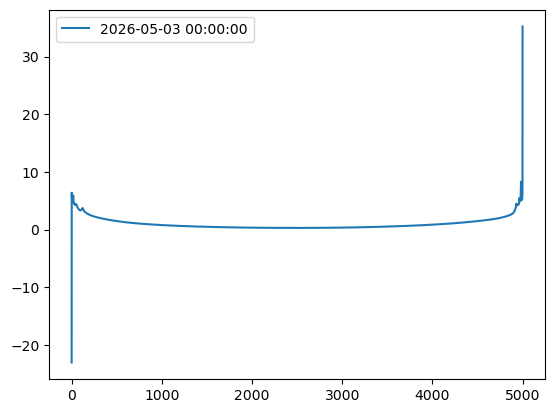

In [15]:
mdfpc_fc["future_L2_curves"].plot()

In [16]:
mdfpc_fc["future_L2_curves"]

,2026-05-03
0,-23.050513
1,6.386608
2,5.821336
3,5.517516
4,5.319355
...,...
4996,5.435637
4997,5.614768
4998,5.900694
4999,6.447028


<Axes: >

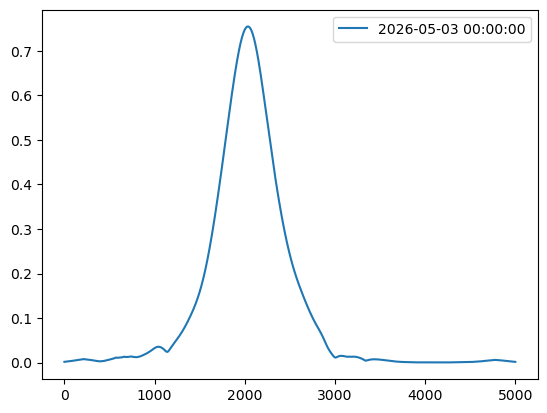

In [17]:
mdfpc_fc["future_densities"].plot()

In [23]:
kdfpc_kwargs = KdFPC_kwargs

In [24]:
kde_train.iloc[:,[0,56]]

,2026-01-24,2026-03-21
-29.030368,0.000000e+00,4.658014e-266
-29.020966,0.000000e+00,8.115421e-266
-29.011564,0.000000e+00,1.413548e-265
-29.002162,0.000000e+00,2.461498e-265
-28.992760,0.000000e+00,4.285265e-265
...,...,...
17.941232,2.302781e-313,5.331125e-86
17.950634,8.531772e-314,3.902642e-86
17.960036,3.158831e-314,2.856196e-86
17.969437,1.168730e-314,2.089809e-86


In [25]:
mlqdt = lqdt.mLQDT()
model_lqd = mlqdt.transform(
    densities=kde_train,
    densities_supports=kde_train_support, 
    verbose=False
    )
# model_lqd.densities_to_lqdensities(verbose=False)

# 2. L2 Expansion (K_dFPC)
lqd_values  = model_lqd.lqd.values
lqd_support = model_lqd.lqd_support

kdfpc_kwargs.update({
    "u": lqd_support,
    "du": model_lqd.du
})

model_kdfpc = dfpc.K_dFPC(lqd_values)
model_kdfpc.fit(**kdfpc_kwargs)

/opt/anaconda3/envs/densities4risk/lib/python3.11/site-packages/scipy/interpolate/_interpolate.py:501: RuntimeWarning: overflow encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
/opt/anaconda3/envs/densities4risk/lib/python3.11/site-packages/scipy/interpolate/_interpolate.py:504: RuntimeWarning: invalid value encountered in multiply
  y_new = slope*(x_new - x_lo)[:, None] + y_lo


<Axes: >

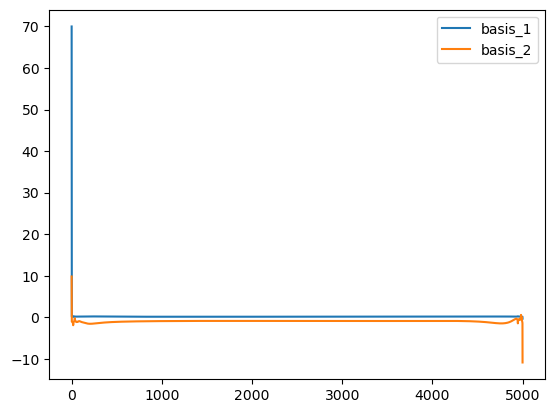

In [26]:
model_kdfpc.psihat.plot()

<Axes: >

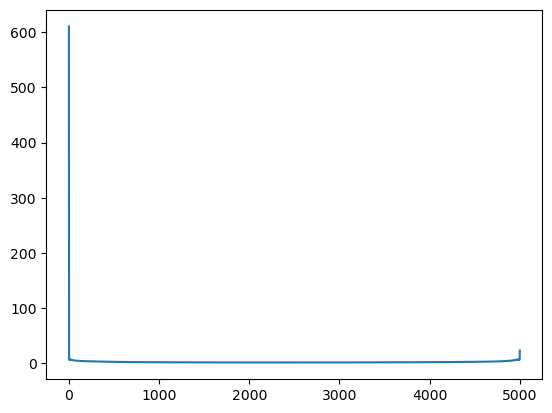

In [27]:
pd.DataFrame(model_kdfpc.fitted_values).iloc[:,56:57].plot(legend=False)

In [28]:
import pmdarima as pm
model_arima = pm.auto_arima(
    model_lqd.c, 
    seasonal=False, 
    information_criterion='bic',
    suppress_warnings=True
)

In [31]:
k_scores = model_kdfpc.etahat.values.real
k_etahat_fc = fp.run_multivariate_forecaster(
    k_scores, 10, 'bic', 1, selected_nlags=None
)

# 2. Forecast 'c'
c_forecast = model_arima.predict(n_periods=1)

# 3. Reconstruct LQD
L2_curve_forecast = model_kdfpc.predict(k_etahat_fc)
L2_curve_forecast.columns = test_kde_dens.iloc[:,-1:].columns

fc_lqd_obj = lqdt.LQDRepresentation(
                    lqd         = L2_curve_forecast,
                    c           = c_forecast,
                    lqd_support = model_lqd.lqd_support,
                    t0          = model_lqd.t0 
                    )

# 4. Back to densities
mlqdt = lqdt.mLQDT()
df_supports, df_densities = mlqdt.inverse_transform(fc_lqd_obj)

<Axes: >

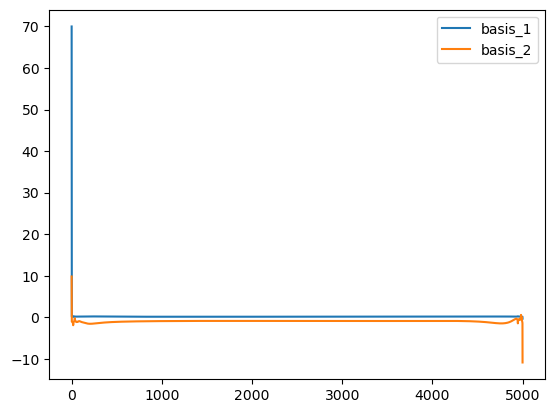

In [32]:
model_kdfpc.psihat.plot()

In [71]:
from src.fda.kde.utils import verify_density_area

<Axes: >

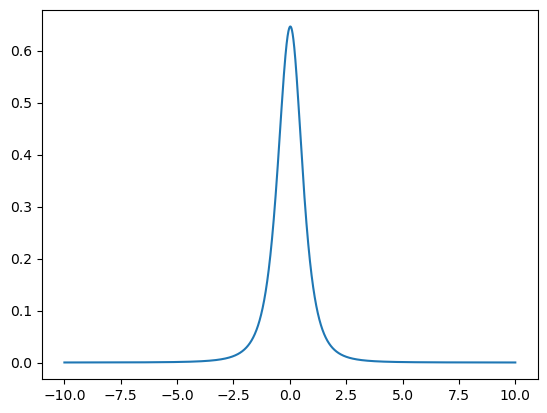

In [74]:
simulations_database["scenario_2___nu=3"]["replications"][37]["densities"].iloc[:,-1].plot()

<Axes: >

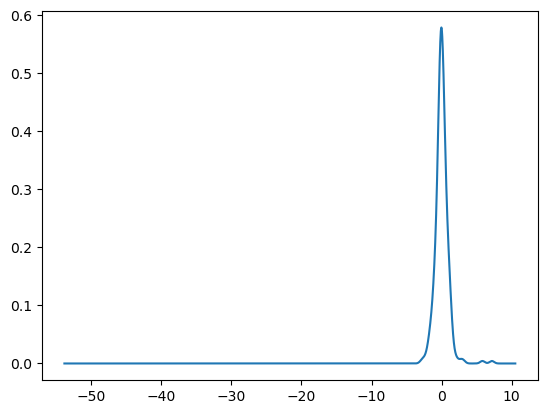

In [80]:
scenario_kde_dict = joblib.load("../data/interim/simulation/20260503/progress/scenario_2___nu=3___rep_37___kde_gaussian_rot.jbl")
df_support, df_densities = scenario_kde_dict["df_support"], scenario_kde_dict["df_densities"]
df_densities.iloc[:,-1].plot()

In [81]:
df_cv_3

,scenario,n_rep,model_name,fold,comparison,fc_date,KLD,JSD,L_1,L_2,L_INFTY,curves,scenario_id,t_df
2,scenario_2___nu=3,0,gaussian rot,1,fHatFc_f,2026-05-03,0.059228,0.003489,32.981068,1.335311,0.114856,actual forecast...,scenario_2,nu=3
8,scenario_2___nu=3,1,gaussian rot,1,fHatFc_f,2026-05-03,0.080338,0.005617,40.353318,1.664975,0.139102,actual forecast...,scenario_2,nu=3
14,scenario_2___nu=3,2,gaussian rot,1,fHatFc_f,2026-05-03,0.089806,0.006190,43.706799,1.666821,0.137888,actual forecast...,scenario_2,nu=3
20,scenario_2___nu=3,3,gaussian rot,1,fHatFc_f,2026-05-03,0.041480,0.001524,21.931731,0.765878,0.050813,actual forecast...,scenario_2,nu=3
26,scenario_2___nu=3,4,gaussian rot,1,fHatFc_f,2026-05-03,0.037262,0.000700,15.889939,0.469988,0.027043,actual forecast...,scenario_2,nu=3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2972,scenario_2___nu=3,495,gaussian rot,1,fHatFc_f,2026-05-03,0.062520,0.002886,30.124946,1.015637,0.064031,actual forecast...,scenario_2,nu=3
2978,scenario_2___nu=3,496,gaussian rot,1,fHatFc_f,2026-05-03,0.160546,0.011689,60.175359,2.403286,0.208357,actual forecast...,scenario_2,nu=3
2984,scenario_2___nu=3,497,gaussian rot,1,fHatFc_f,2026-05-03,0.106866,0.007764,48.949314,1.933683,0.163015,actual forecast...,scenario_2,nu=3
2990,scenario_2___nu=3,498,gaussian rot,1,fHatFc_f,2026-05-03,0.059044,0.003352,33.584100,1.368476,0.121712,actual forecast...,scenario_2,nu=3


In [38]:
curves

,support,actual,forecast
0,-21.330461,0.000076,0.0
1,-21.321275,0.000076,0.0
2,-21.312090,0.000076,0.0
3,-21.302904,0.000076,0.0
4,-21.293718,0.000077,0.0
...,...,...,...
4996,24.560978,0.000082,0.0
4997,24.570163,0.000082,0.0
4998,24.579349,0.000082,0.0
4999,24.588535,0.000082,0.0


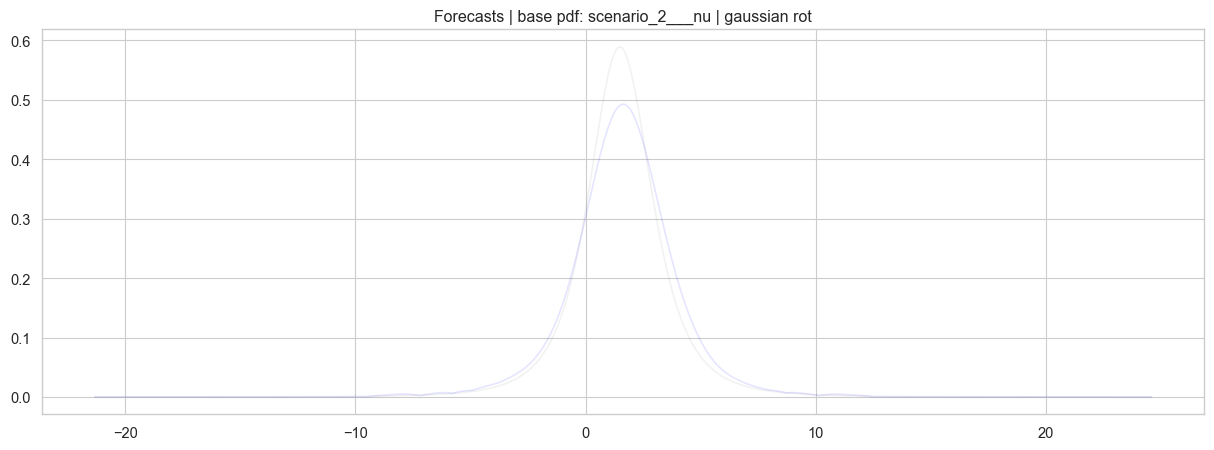

In [54]:
plt.figure(figsize=(15,5))
plt.plot(curves.index, curves["actual"], color="gray", alpha=0.1)
plt.plot(curves.index, curves["forecast"], color="blue", alpha=0.1)
# nrep= x["n_rep"]
# curves.plot(title=f"{nrep}")
plt.title(f"Forecasts | base pdf: scenario_2___nu | gaussian rot")
plt.show()

In [66]:
df_cv_3.iloc[:,-1:]

,t_df
0,nu=3
1,nu=3
2,nu=3
6,nu=3
7,nu=3
...,...
2989,nu=3
2990,nu=3
2994,nu=3
2995,nu=3


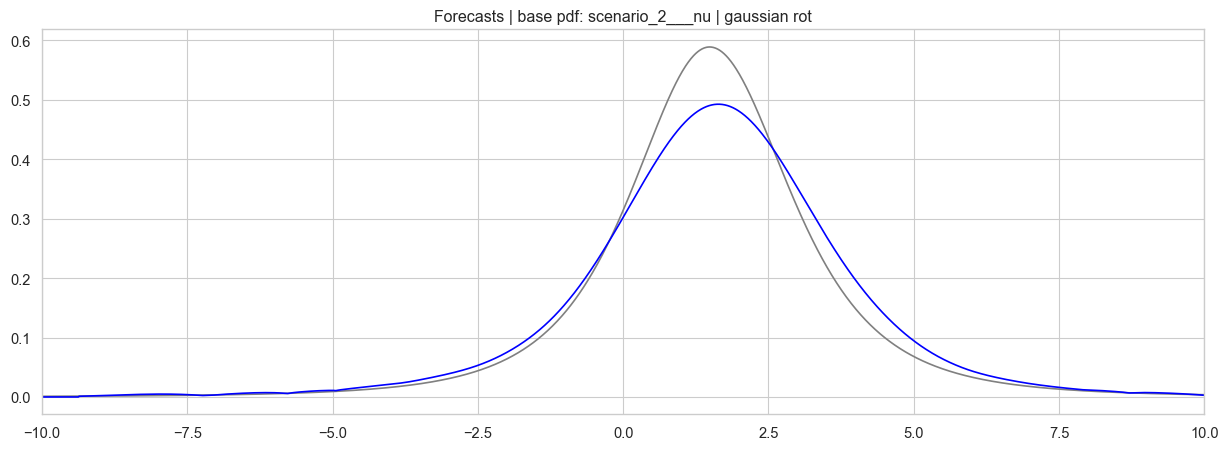

In [60]:
plt.figure(figsize=(15,5))
plt.plot(curves.index, curves["actual"], color="gray")
plt.plot(curves.index, curves["forecast"], color="blue")
plt.xlim([-10,10])
plt.title(f"Forecasts | base pdf: scenario_2___nu | gaussian rot")
plt.show()